# ML-сигналы: frozen policy $h_{train}=11 \rightarrow h_{eval}=10$

Модель обучается на

$$good\_push_{T,11}=truth\_now_{T,11}\land[benefit_{T,11}>0].$$

Параметры policy заморожены по прежнему inner-OOF выбору на $h=11$. Горизонт
$h=10$ не участвует в обучении или выборе порога и используется только для
официальной оценки:

$$truth\_now_{T,10}=\mathbf{1}\left[P_T\leq\min(P_{T+1:T+10})\right],$$

$$lift_{10}=\frac{hit\_rate_{signal,10}}{hit\_rate_{random,10}},$$

$$benefit_{T,10}=\left(\frac{mean(P_{T-10:T+10})}{P_T}-1\right)10\,000.$$

USD/EUR/CNY используются как причинные контекстные признаки. Частота не входит
в selection. Период 2023–2026 уже использовался при разработке и не является
новым pristine holdout.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RESULT_DIR = ROOT / 'data' / 'processed' / 'ml_cross_h_11_to_10'
HARD_RESULT_DIR = ROOT / 'data' / 'processed' / 'hard_signals'
metrics = pd.read_csv(RESULT_DIR/'fold_metrics.csv', parse_dates=['fold_start','fold_end','effective_evaluation_end'])
rolling = pd.read_csv(RESULT_DIR/'rolling_window_metrics.csv', parse_dates=['fold_start','fold_end'])
final_h = pd.read_csv(RESULT_DIR/'final_2025_2026_by_horizon.csv', parse_dates=['fold_start','fold_end'])
final_h_summary = pd.read_csv(RESULT_DIR/'final_2025_2026_summary_by_horizon.csv', parse_dates=['evaluation_end_exclusive'])
# Единое требуемое правило: односторонний H1 mean(benefit)>0, alpha=5%.
# CI показывается отдельно и не участвует в булевом вердикте.
for frame in (metrics, rolling, final_h):
    frame['benefit_significant_5pct'] = frame['benefit_p_value_vs_zero'].lt(.05)
choices = pd.read_csv(RESULT_DIR/'outer_choices.csv', parse_dates=['outer_start','effective_evaluation_end'])
hard_report = pd.read_csv(HARD_RESULT_DIR/'hard_indicator_corridor_report.csv')
with (RESULT_DIR/'metadata.json').open(encoding='utf-8') as f: metadata=json.load(f)
currencies=['AMD','KGS','KZT','TJS','UZS']
plt.rcParams.update({'figure.dpi':120, 'axes.titlesize':11, 'figure.titlesize':14})
print(f"Данные по {metadata['data_as_of']}; context features: {len(metadata['context_feature_columns'])}")

Данные по 2026-09-02; context features: 14


## Итоговый отчёт по hard-индикаторам

Матрица ниже построена по честным walk-forward сигналам последних трёх лет.
Для каждой пары `индикатор × коридор` показан худший результат среди
$h=2/3/4/5$. Самостоятельный hard-trigger допускается только если на всех этих
горизонтах одновременно выполнены три условия: $lift\geq1.3$, средняя
экономическая выгода положительна и её односторонний тест значим на уровне 5%.

Ни один hard-индикатор этот фильтр устойчиво не прошёл. Поэтому hard-правила
**не определяют даты отправки** и не входят в финансовые метрики финального
потока. Momentum, низкий уровень и выход вниз при этом показывают положительную
среднюю выгоду на всех проверенных горизонтах. Они сохраняются как причинные
факты для текста уже независимо выбранного ML-пуша, только если соответствующее
условие действительно наблюдается на дату $T$.

Это не использует будущий `benefit` конкретного события: право семейства быть
текстовым reason фиксируется по прошлому walk-forward отчёту, а сам текст на
дате $T$ выбирается исключительно из доступных на $T$ hard-признаков. Выход
вверх исключён и из этой роли: его выгода для сценария «сейчас выгодно» не
положительна.

In [2]:
hard_matrix=(hard_report[[
    'indicator','corridor','worst_horizon',
    'hit_rate_signal_at_worst_lift','hit_rate_random_at_worst_lift',
    'min_hit_lift','median_hit_lift','min_benefit_bps','median_benefit_bps',
    'benefit_significant_all_h','standalone_trigger','ml_message_fact_eligible',
    'reason',
]].rename(columns={
    'indicator':'индикатор','corridor':'коридор','worst_horizon':'худший h',
    'hit_rate_signal_at_worst_lift':'hit rate сигнала',
    'hit_rate_random_at_worst_lift':'hit rate случайного дня',
    'min_hit_lift':'минимальный lift','median_hit_lift':'медианный lift',
    'min_benefit_bps':'минимальная выгода, bp',
    'median_benefit_bps':'медианная выгода, bp',
    'benefit_significant_all_h':'benefit значим на всех h',
    'standalone_trigger':'самостоятельный trigger',
    'ml_message_fact_eligible':'можно использовать как текст ML',
    'reason':'причина исключения',
}))
for column in ['benefit значим на всех h','самостоятельный trigger','можно использовать как текст ML']:
    hard_matrix[column]=hard_matrix[column].map({True:'Да',False:'Нет'})
display(hard_matrix.round(3))

,индикатор,коридор,худший h,hit rate сигнала,hit rate случайного дня,минимальный lift,медианный lift,"минимальная выгода, bp","медианная выгода, bp",benefit значим на всех h,самостоятельный trigger,можно использовать как текст ML,причина исключения
0,Выход вниз из коридора,RUB→AMD,3,0.333,0.354,0.942,1.016,26.041,34.396,Да,Нет,Да,lift ниже 1.3
1,Выход вниз из коридора,RUB→KGS,3,0.206,0.346,0.596,0.657,12.795,14.642,Нет,Нет,Да,lift ниже 1.3; выгода значима не на всех h
2,Выход вниз из коридора,RUB→KZT,2,0.407,0.394,1.034,1.067,67.156,78.200,Да,Нет,Да,lift ниже 1.3
3,Выход вниз из коридора,RUB→TJS,2,0.343,0.428,0.801,0.864,65.615,75.696,Да,Нет,Да,lift ниже 1.3
4,Выход вниз из коридора,RUB→UZS,3,0.227,0.354,0.643,0.765,38.670,45.668,Да,Нет,Да,lift ниже 1.3
5,Выход вверх из коридора,RUB→AMD,4,0.586,0.510,1.149,1.231,-10.480,-6.298,Нет,Нет,Нет,lift ниже 1.3; выгода не положительна
6,Выход вверх из коридора,RUB→KGS,5,0.667,0.512,1.302,1.499,-33.058,-23.626,Нет,Нет,Нет,выгода не положительна
7,Выход вверх из коридора,RUB→KZT,3,0.615,0.505,1.219,1.273,-70.105,-64.024,Нет,Нет,Нет,lift ниже 1.3; выгода не положительна
8,Выход вверх из коридора,RUB→TJS,4,0.769,0.530,1.451,1.475,-16.538,-6.848,Нет,Нет,Нет,выгода не положительна
9,Выход вверх из коридора,RUB→UZS,3,0.667,0.501,1.331,1.448,-31.644,-17.486,Нет,Нет,Нет,выгода не положительна


**Прямой вывод.** Momentum, низкий уровень и выход вниз исключаются
как самостоятельные триггеры из-за недостаточного hit-rate lift, но остаются
разрешёнными объясняющими фактами для ML-пуша. Выход вверх исключается полностью
из сценария «сейчас выгодно»: lift местами высокий, однако экономическая выгода
отрицательна. Финальным финансовым индикатором остаётся только ML-policy;
hard-факт влияет на формулировку, но не на решение об отправке.

## 1. Замороженные параметры и границы оценки

In [3]:
display(choices[['outer_start','effective_evaluation_end','model_config','score_lookback','joint_quantile']])

,outer_start,effective_evaluation_end,model_config,score_lookback,joint_quantile
0,2023-01-01,2023-12-31,deep_regularized,60,0.825
1,2024-01-01,2024-12-30,deep_smooth,504,0.800
2,2025-01-01,2026-01-01,deep_smooth,504,0.800
3,2026-01-01,2026-08-19,baseline_long,504,0.700


## 2. Финальная оценка 2025–2026 на всех обязательных горизонтах

Здесь оценивается **один и тот же замороженный поток OOT-пушей** модели,
обученной с target $h_{train}=11$. Горизонт $h$ меняет только последующую
проверку исхода, но не даты пушей. Поэтому частота одинакова во всех столбцах.

Чтобы сравнение было честным, справа используется единая граница созревания:
во все столбцы входят только даты, для которых уже известны следующие 20
публикаций. Для каждого $h$ отдельно пересчитываются

$$lift_h=\frac{hit\_rate_{signal,h}}{hit\_rate_{random,h}},$$

$$benefit_{T,h}=\left(\frac{mean(P_{T-h:T+h})}{P_T}-1\right)\cdot10\,000\;bp.$$

Это профиль устойчивости выбранной policy по клиентскому горизонту, а не пять
заново настроенных моделей.

Финальное окно: 2025-01-01 — 2026-08-05 (единая зрелость h=20)


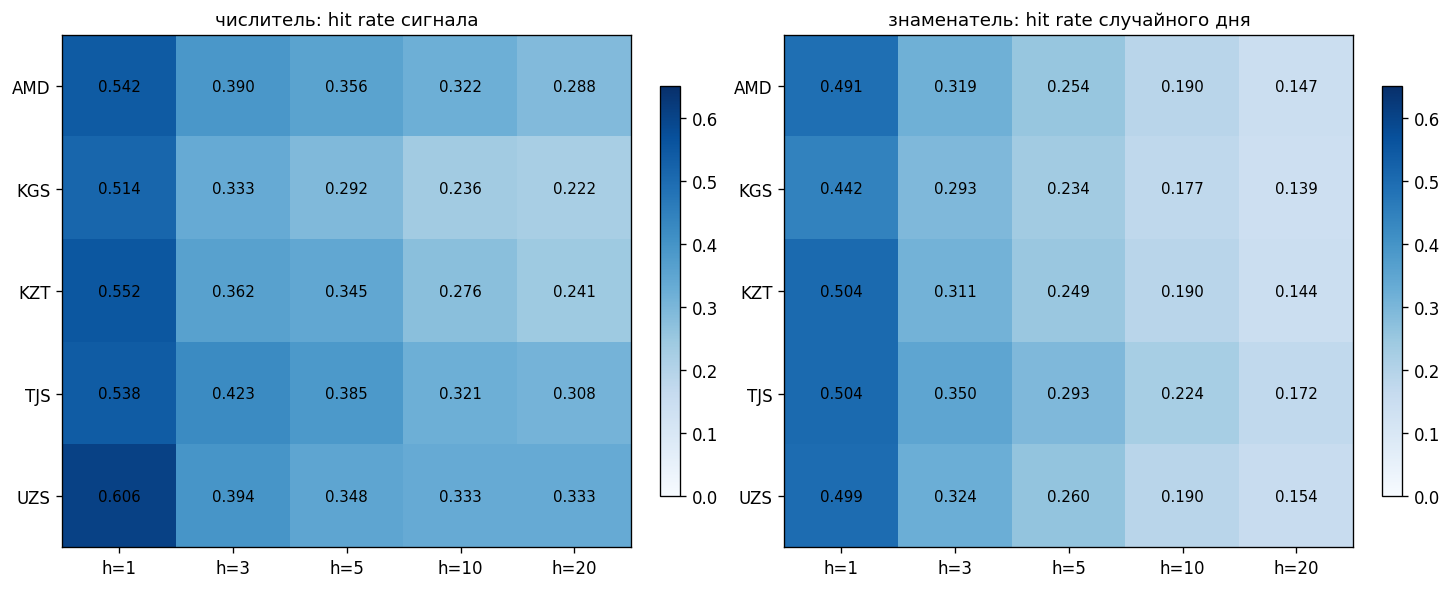

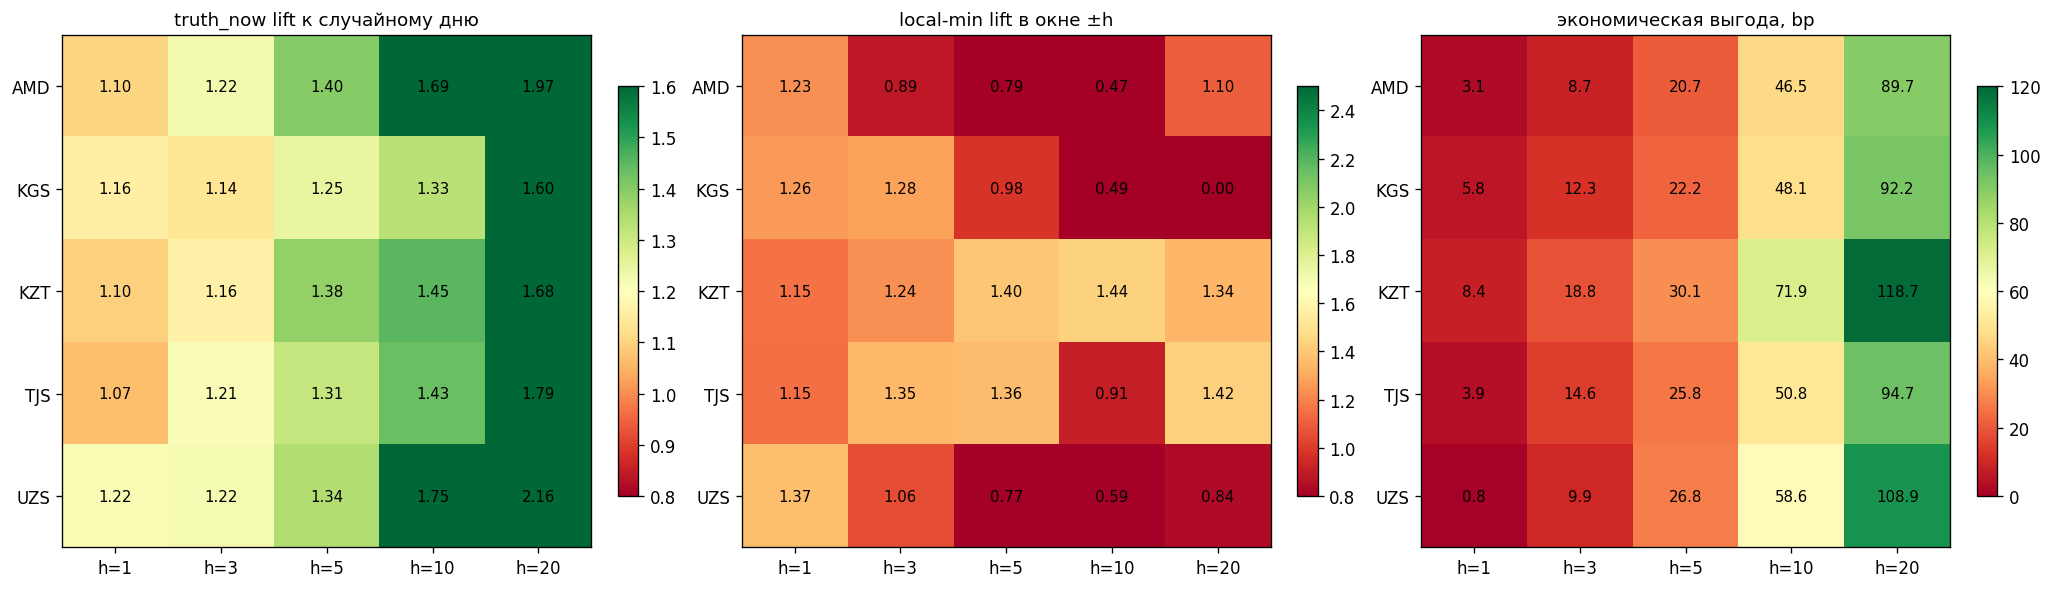

,h,Hit rate сигнала,Hit rate случайного дня,Средний lift,Минимальный lift,"Средняя выгода, bp",Значима для всех валют
0,1,0.542,0.499,1.129,1.069,4.389,Нет
1,3,0.390,0.319,1.190,1.137,12.862,Нет
2,5,0.348,0.254,1.337,1.247,25.121,Да
3,10,0.321,0.190,1.532,1.331,55.183,Да
4,20,0.288,0.147,1.838,1.601,100.847,Да


In [4]:
evaluation_end=(final_h_summary.evaluation_end_exclusive.min()-pd.Timedelta(days=1)).date()
print(f'Финальное окно: 2025-01-01 — {evaluation_end} (единая зрелость h=20)')

fig,axes=plt.subplots(1,2,figsize=(12,4.8),constrained_layout=True)
for ax,column,title in [
    (axes[0],'truth_now_hit_rate','числитель: hit rate сигнала'),
    (axes[1],'truth_now_random','знаменатель: hit rate случайного дня'),
]:
    matrix=(final_h.pivot(index='currency',columns='horizon',values=column)
                   .reindex(index=currencies,columns=[1,3,5,10,20]))
    image=ax.imshow(matrix.to_numpy(),aspect='auto',cmap='Blues',vmin=0,vmax=.65)
    ax.set_xticks(range(len(matrix.columns)),[f'h={h}' for h in matrix.columns])
    ax.set_yticks(range(len(currencies)),currencies); ax.set_title(title)
    for i in range(len(currencies)):
        for j in range(len(matrix.columns)):
            value=matrix.iloc[i,j]
            ax.text(j,i,f'{value:.3f}' if pd.notna(value) else '—',ha='center',va='center',fontsize=9)
    fig.colorbar(image,ax=ax,shrink=.8)
plt.show()

fig,axes=plt.subplots(1,3,figsize=(17,4.8),constrained_layout=True)
for ax,column,title,vmin,vmax,fmt in [
    (axes[0],'truth_now_lift','truth_now lift к случайному дню',0.8,1.6,'.2f'),
    (axes[1],'local_min_lift','local-min lift в окне ±h',0.8,2.5,'.2f'),
    (axes[2],'benefit_bps','экономическая выгода, bp',0,120,'.1f'),
]:
    matrix=(final_h.pivot(index='currency',columns='horizon',values=column)
                   .reindex(index=currencies,columns=[1,3,5,10,20]))
    image=ax.imshow(matrix.to_numpy(),aspect='auto',cmap='RdYlGn',vmin=vmin,vmax=vmax)
    ax.set_xticks(range(len(matrix.columns)),[f'h={h}' for h in matrix.columns])
    ax.set_yticks(range(len(currencies)),currencies); ax.set_title(title)
    for i in range(len(currencies)):
        for j in range(len(matrix.columns)):
            value=matrix.iloc[i,j]
            ax.text(j,i,format(value,fmt) if pd.notna(value) else '—',ha='center',va='center',fontsize=9)
    fig.colorbar(image,ax=ax,shrink=.8)
plt.show()

summary_table=(final_h_summary[[
    'horizon','median_truth_hit_rate','median_truth_random',
    'mean_truth_lift','min_truth_lift','mean_benefit_bps',
    'all_benefits_significant',
]].rename(columns={
    'horizon':'h',
    'median_truth_hit_rate':'Hit rate сигнала',
    'median_truth_random':'Hit rate случайного дня',
    'mean_truth_lift':'Средний lift',
    'min_truth_lift':'Минимальный lift',
    'mean_benefit_bps':'Средняя выгода, bp',
    'all_benefits_significant':'Значима для всех валют',
}))
summary_table['Значима для всех валют'] = summary_table['Значима для всех валют'].map(
    {True:'Да', False:'Нет'}
)
display(summary_table.round(3))

В следующей таблице lift рассчитывается **внутри каждой строки** как
`hit_rate_signal / hit_rate_random`. Поэтому медианный lift по пяти валютам
может отличаться от отношения двух медианных hit rate.

In [5]:
detail=(final_h[['horizon','currency','truth_now_hit_rate','truth_now_random',
                         'truth_now_lift','benefit_bps','benefit_ci_low_95',
                         'benefit_ci_high_95','benefit_significant_5pct']]
        .sort_values(['horizon','currency']))
display(detail.round(3))

,horizon,currency,truth_now_hit_rate,truth_now_random,truth_now_lift,benefit_bps,benefit_ci_low_95,benefit_ci_high_95,benefit_significant_5pct
0,1,AMD,0.542,0.491,1.105,3.103,-8.530,9.521,False
1,1,KGS,0.514,0.442,1.162,5.792,-0.253,10.185,True
2,1,KZT,0.552,0.504,1.095,8.425,0.175,18.321,True
3,1,TJS,0.538,0.504,1.069,3.856,-0.996,8.569,False
4,1,UZS,0.606,0.499,1.215,0.768,-5.334,7.108,False
5,3,AMD,0.390,0.319,1.223,8.721,-8.266,20.810,False
6,3,KGS,0.333,0.293,1.137,12.254,1.693,23.595,True
7,3,KZT,0.362,0.311,1.164,18.846,1.218,41.878,True
8,3,TJS,0.423,0.350,1.210,14.570,1.332,24.232,True
9,3,UZS,0.394,0.324,1.216,9.920,-3.730,23.305,False


## 3. Честные годовые outer-метрики

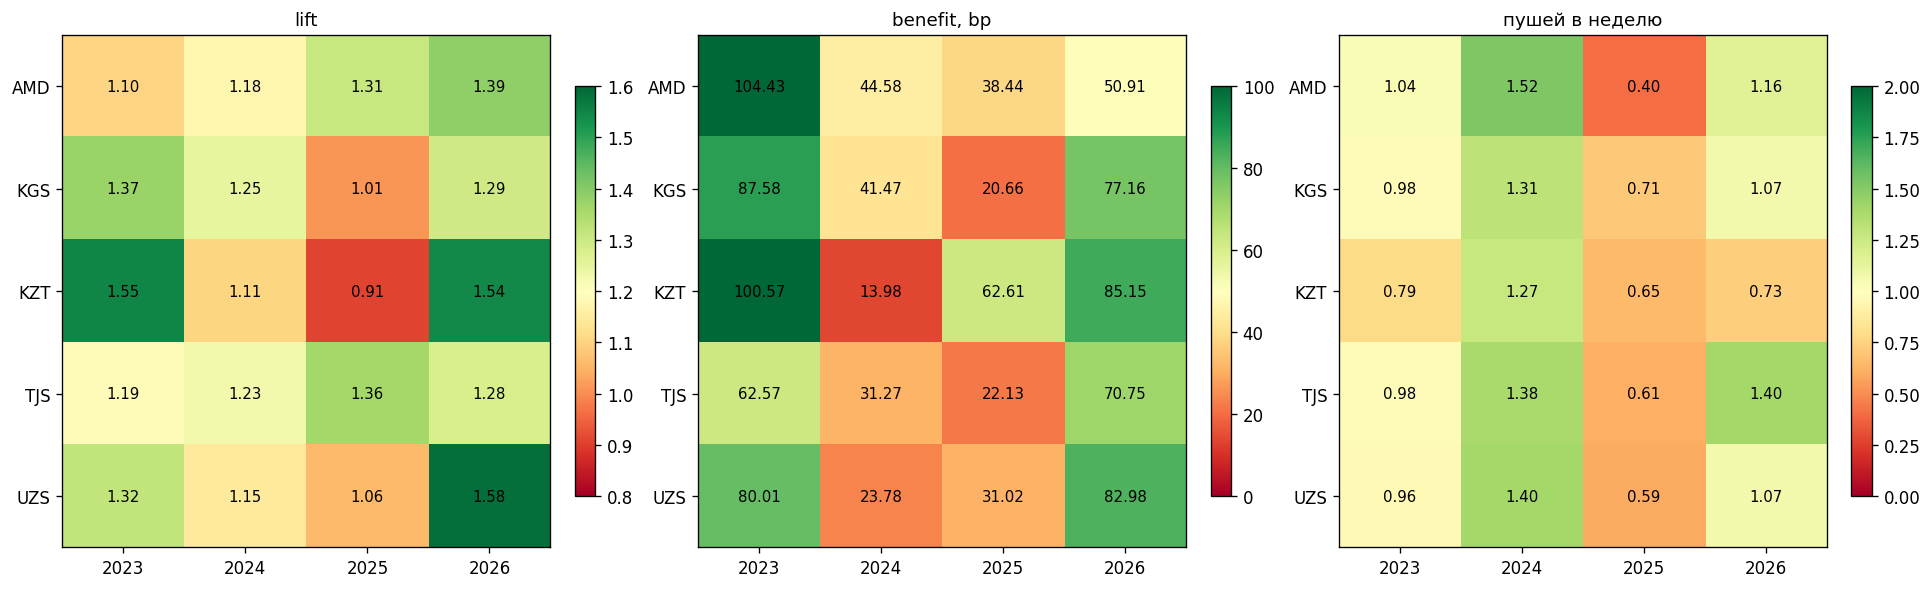

In [6]:
annual=metrics.assign(year=metrics.fold_start.dt.year)
fig,axes=plt.subplots(1,3,figsize=(16,4.8),constrained_layout=True)
specs=[('truth_now_lift','lift',0.8,1.6),('benefit_bps','benefit, bp',0,100),('signals_per_week','пушей в неделю',0,2)]
for ax,(column,title,vmin,vmax) in zip(axes,specs):
    matrix=annual.pivot(index='currency',columns='year',values=column).reindex(currencies)
    image=ax.imshow(matrix.to_numpy(),aspect='auto',cmap='RdYlGn',vmin=vmin,vmax=vmax)
    ax.set_xticks(range(len(matrix.columns)),matrix.columns); ax.set_yticks(range(len(currencies)),currencies); ax.set_title(title)
    for i in range(len(currencies)):
        for j in range(len(matrix.columns)):
            ax.text(j,i,f'{matrix.iloc[i,j]:.2f}',ha='center',va='center',fontsize=9)
    fig.colorbar(image,ax=ax,shrink=.8)
plt.show()

Зелёный годовой lift должен сохраняться по валютам, а не только после объединения нескольких лет.

## 4. Объединённые trailing OOT-окна

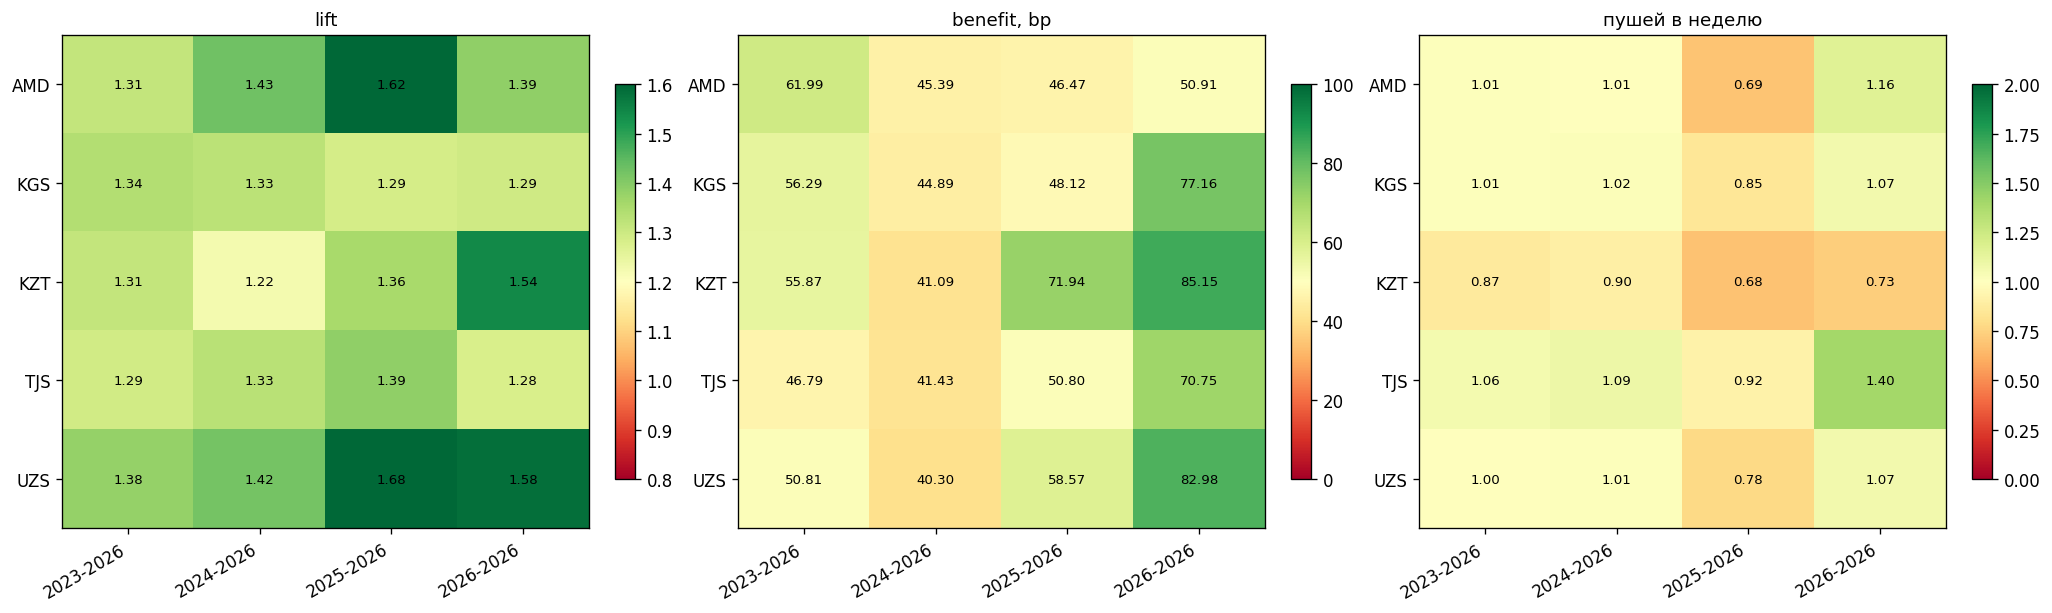

In [7]:
windows=list(dict.fromkeys(rolling.window))
fig,axes=plt.subplots(1,3,figsize=(17,5),constrained_layout=True)
for ax,(column,title,vmin,vmax) in zip(axes,specs):
    matrix=rolling.pivot(index='currency',columns='window',values=column).reindex(index=currencies,columns=windows)
    image=ax.imshow(matrix.to_numpy(),aspect='auto',cmap='RdYlGn',vmin=vmin,vmax=vmax)
    ax.set_xticks(range(len(windows)),windows,rotation=30,ha='right'); ax.set_yticks(range(len(currencies)),currencies); ax.set_title(title)
    for i in range(len(currencies)):
        for j in range(len(windows)):
            ax.text(j,i,f'{matrix.iloc[i,j]:.2f}',ha='center',va='center',fontsize=8)
    fig.colorbar(image,ax=ax,shrink=.8)
plt.show()

## 5. Полные обязательные метрики

In [8]:
columns=['window','currency','signal_count','signals_per_week','truth_now_hit_rate','truth_now_random','truth_now_lift','benefit_bps','benefit_ci_low_95','benefit_ci_high_95','benefit_significant_5pct','clustered_share_within_5_observations']
display(rolling[columns].round(3))

,window,currency,signal_count,signals_per_week,truth_now_hit_rate,truth_now_random,truth_now_lift,benefit_bps,benefit_ci_low_95,benefit_ci_high_95,benefit_significant_5pct,clustered_share_within_5_observations
0,2023-2026,AMD,192,1.014,0.339,0.258,1.314,61.992,30.151,88.101,True,0.828
1,2023-2026,KGS,191,1.008,0.330,0.246,1.339,56.289,38.635,73.956,True,0.812
2,2023-2026,KZT,165,0.871,0.297,0.226,1.313,55.870,20.304,86.773,True,0.800
3,2023-2026,TJS,201,1.061,0.338,0.262,1.291,46.792,26.543,66.227,True,0.796
4,2023-2026,UZS,189,0.998,0.339,0.245,1.381,50.806,30.754,69.589,True,0.799
5,2024-2026,AMD,138,1.005,0.333,0.234,1.426,45.388,17.170,76.306,True,0.826
6,2024-2026,KGS,140,1.020,0.300,0.226,1.327,44.890,27.982,63.856,True,0.843
7,2024-2026,KZT,124,0.903,0.250,0.204,1.223,41.090,2.842,79.831,True,0.823
8,2024-2026,TJS,150,1.093,0.340,0.255,1.331,41.427,18.817,62.948,True,0.807
9,2024-2026,UZS,139,1.012,0.317,0.223,1.420,40.301,16.300,63.749,True,0.827


# 6. Кучность ML и обязательные напоминания 5/20

Здесь разделены два разных продукта.

1. **ML-пуш «сейчас выгодно».** Только для него считаются hit rate, lift и
   экономическая выгода — это результаты раздела 2 без каких-либо календарных
   сообщений.
2. **CRM-напоминание.** Оно сообщает о плановой дате и предзаполненном переводе,
   не утверждает, что курс выгоден, поэтому lift и benefit для него не имеют
   смысла. После объединения считаются только частота и равномерность коммуникаций.

На валютный коридор разрешено не более двух **ML-пушей** в календарную неделю:
после отправленного ML-пуша сигнал следующего календарного дня подавляется, а
из остальных причинно сохраняются не более двух с понедельника по воскресенье.
Отклонённый соседний сигнал не занимает недельную квоту, поэтому более поздний
сигнал той же недели ещё может быть отправлен. После этого ровно 5-го и 20-го
всегда отправляется отдельный CRM-reminder — даже если
рядом или в тот же день есть ML. Для него недельный лимит не применяется,
поэтому общий поток иногда содержит три сообщения за неделю: эта календарная
скученность разрешена постановкой эксперимента.

Reminder не участвует в финансовой оценке. Lift и benefit ниже пересчитаны
только на ML-сигналах, оставшихся после ML-лимита.

In [9]:
reminder_distribution = pd.read_csv(RESULT_DIR/'reminder_distribution.csv')
reminder_coverage = pd.read_csv(RESULT_DIR/'reminder_coverage.csv')
reminders = pd.read_csv(RESULT_DIR/'calendar_reminders.csv', parse_dates=['date','calendar_anchor'])
combined = pd.read_csv(RESULT_DIR/'ml_plus_reminders.csv.gz', parse_dates=['date','calendar_anchor'])
communication_metrics = pd.read_csv(RESULT_DIR/'communication_ml_by_horizon.csv')
communication_summary = pd.read_csv(RESULT_DIR/'communication_summary_by_horizon.csv')
display(reminder_coverage.round(3))

,currency,anchors,reminders_emitted,attractive_reminders,anchor_coverage
0,AMD,39,39,10,1.0
1,KGS,39,39,13,1.0
2,KZT,39,39,11,1.0
3,TJS,39,39,8,1.0
4,UZS,39,39,12,1.0


## 6.1 Финансовые метрики относятся только к ML

Reminder-даты не входят ни в числитель, ни в случайный baseline, ни в benefit.
Но недельный лимит меняет набор реально отправленных ML-сигналов, поэтому
финансовые метрики пересчитаны по оставшимся ML-дням. Значимость определяется
односторонним тестом $H_1:\mathbb{E}[benefit]>0$ при $\alpha=0.05$; двухсторонний
95% CI остаётся диагностикой и не входит в флаг `Да/Нет`.

In [10]:
ml_quality=communication_summary[[
    'horizon','median_truth_hit_rate','median_truth_random',
    'mean_truth_lift','min_truth_lift','mean_benefit_bps',
    'min_benefit_bps','all_benefits_significant',
    'mean_ml_pushes_per_week','mean_total_pushes_per_week',
]].rename(columns={
    'horizon':'h','median_truth_hit_rate':'hit rate ML','median_truth_random':'random hit rate',
    'mean_truth_lift':'средний lift','min_truth_lift':'минимальный lift',
    'mean_benefit_bps':'средняя выгода, bp','min_benefit_bps':'минимальная выгода, bp',
    'all_benefits_significant':'benefit значим для всех валют',
    'mean_ml_pushes_per_week':'средняя частота ML','mean_total_pushes_per_week':'средняя частота всего',
})
display(ml_quality.round(3))

,h,hit rate ML,random hit rate,средний lift,минимальный lift,"средняя выгода, bp","минимальная выгода, bp",benefit значим для всех валют,средняя частота ML,средняя частота всего
0,1,0.558,0.499,1.152,1.078,6.803,1.279,False,0.484,0.953
1,3,0.353,0.319,1.161,1.102,14.008,10.575,False,0.484,0.953
2,5,0.341,0.254,1.308,1.260,24.757,21.736,True,0.484,0.953
3,10,0.294,0.190,1.481,1.352,51.529,41.435,True,0.484,0.953
4,20,0.265,0.147,1.762,1.588,94.814,76.008,True,0.484,0.953


## 6.1.1 Детализация по валютам на основном горизонте h=10

Это основной горизонт замороженной policy `h_train=11 → h_eval=10`.
Доверительный интервал и p-value относятся только к средней выгоде ML-пушей.

In [11]:
total_frequency=(reminder_distribution.loc[
    reminder_distribution.stream.eq('ML cap + mandatory 5/20'),
    ['currency','signals_per_week'],
].rename(columns={'signals_per_week':'все пуши/нед.'}))
h10_currency=(communication_metrics.loc[communication_metrics.horizon.eq(10),[
    'currency','truth_now_hit_rate','truth_now_random','truth_now_lift',
    'benefit_bps','benefit_ci_low_95','benefit_ci_high_95',
    'benefit_p_value_vs_zero','benefit_significant_5pct','signals_per_week',
]].merge(total_frequency,on='currency').rename(columns={
    'currency':'валюта','truth_now_hit_rate':'hit rate ML',
    'truth_now_random':'random hit rate','truth_now_lift':'lift',
    'benefit_bps':'benefit, bp','benefit_ci_low_95':'CI 95% low',
    'benefit_ci_high_95':'CI 95% high','benefit_p_value_vs_zero':'p-value',
    'benefit_significant_5pct':'benefit значим','signals_per_week':'ML/нед.',
}))
display(h10_currency.round(3))

,валюта,hit rate ML,random hit rate,lift,"benefit, bp",CI 95% low,CI 95% high,p-value,benefit значим,ML/нед.,все пуши/нед.
0,AMD,0.294,0.190,1.546,41.435,9.094,65.075,0.010,True,0.409,0.878
1,KGS,0.256,0.177,1.442,45.853,13.120,70.308,0.003,True,0.517,0.986
2,KZT,0.257,0.190,1.352,65.209,8.983,123.864,0.013,True,0.421,0.890
3,TJS,0.311,0.224,1.391,47.165,18.562,71.996,0.003,True,0.541,1.010
4,UZS,0.318,0.190,1.673,57.981,21.214,97.942,0.010,True,0.529,0.998


## 6.2 Кучность отправленных ML-пушей

Здесь анализируются только ML-пуши после ограничения «не более двух в неделю»
и запрета отправки два календарных дня подряд. Напоминания 5/20 исключены.

Для последовательных ML-пушей считаем календарный интервал
$\Delta_i=(T_i-T_{i-1})$ в днях. Например, `q90 = 30` означает, что 90% пауз
между соседними ML-пушами не превышают 30 дней. Число и доля активных недель
показывают, насколько равномерно ML-пуши покрывают тестовый период.

In [12]:
ml_clustering=(reminder_distribution.loc[
    reminder_distribution.stream.eq('ML weekly cap + day gap'),[
        'currency','active_week_count','total_week_count','active_week_share',
        'gap_calendar_days_q90','gap_calendar_days_q95','gap_calendar_days_q99',
        'max_gap_calendar_days',
    ]].rename(columns={
        'currency':'валюта','active_week_count':'недель с ML-пушем',
        'total_week_count':'всего недель','active_week_share':'доля активных недель',
        'gap_calendar_days_q90':'q90 паузы, дней',
        'gap_calendar_days_q95':'q95 паузы, дней',
        'gap_calendar_days_q99':'q99 паузы, дней',
        'max_gap_calendar_days':'максимальная пауза, дней',
    }))
display(ml_clustering.round(3))

,валюта,недель с ML-пушем,всего недель,доля активных недель,"q90 паузы, дней","q95 паузы, дней","q99 паузы, дней","максимальная пауза, дней"
10,AMD,24,84,0.286,35.0,48.0,92.0,92.0
11,KGS,28,84,0.333,35.0,62.0,122.0,122.0
12,KZT,24,84,0.286,41.0,89.0,98.0,98.0
13,TJS,31,84,0.369,33.0,41.0,122.0,122.0
14,UZS,28,84,0.333,41.0,55.0,106.0,106.0


## 6.3 Интерпретация

ML-лимит выполнен: ML-сообщений не больше двух в неделю и они не приходят два
календарных дня подряд. После двух безусловных reminders в месяц средняя частота
равна примерно 0.95, диапазон по валютам 0.88–1.01. Полные месяцы без сообщений
исчезли, максимальная пауза сократилась
до 16 дней.

Новая policy даёт больше коммуникаций, чем строгий общий лимит (0.83), сохраняя
все разрешённые ML-сигналы. Цена — до трёх сообщений в отдельную неделю и
короткие интервалы около календарных дат. Это допустимо только потому, что
reminder является сервисным сообщением, а не повторным заявлением «сейчас
выгодно».

In [13]:
examples=reminders[[
    'date','currency','calendar_anchor','days_from_anchor','reminder_fallback',
    'level_percentile_20','message_fact',
]].sort_values(['date','currency']).head(20)
display(examples)

,date,currency,calendar_anchor,days_from_anchor,reminder_fallback,level_percentile_20,message_fact
0,2025-01-05,AMD,2025-01-05,0,True,0.65,Плановый перевод на 5-е число: сумма и реквизи...
1,2025-01-05,KGS,2025-01-05,0,True,0.60,Плановый перевод на 5-е число: сумма и реквизи...
2,2025-01-05,KZT,2025-01-05,0,True,0.70,Плановый перевод на 5-е число: сумма и реквизи...
3,2025-01-05,TJS,2025-01-05,0,True,0.60,Плановый перевод на 5-е число: сумма и реквизи...
4,2025-01-05,UZS,2025-01-05,0,True,0.65,Плановый перевод на 5-е число: сумма и реквизи...
5,2025-01-20,AMD,2025-01-20,0,True,0.75,Плановый перевод на 20-е число: сумма и реквиз...
6,2025-01-20,KGS,2025-01-20,0,True,0.65,Плановый перевод на 20-е число: сумма и реквиз...
7,2025-01-20,KZT,2025-01-20,0,False,0.80,Напоминание о переводе на 20-е число: курс ниж...
8,2025-01-20,TJS,2025-01-20,0,True,0.55,Плановый перевод на 20-е число: сумма и реквиз...
9,2025-01-20,UZS,2025-01-20,0,True,0.55,Плановый перевод на 20-е число: сумма и реквиз...
